In [1]:
import os

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
# 0 = all messages are logged (default behavior)
# 1 = INFO messages are not printed
# 2 = INFO and WARNING messages are not printed
# 3 = INFO, WARNING, and ERROR messages are not printed

import datetime

import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import seaborn as sns
# import tensorflow as tf
#from google.colab import drive

#drive.mount('/content/gdrive')

mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False

import warnings
# https://stackoverflow.com/questions/15777951/how-to-suppress-pandas-future-warning
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

import logging
tf.get_logger().setLevel(logging.ERROR)

# https://stackoverflow.com/questions/65697623/tensorflow-warning-found-untraced-functions-such-as-lstm-cell-6-layer-call-and
import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

# Data Cleansing, Normalization and Feature Engineering

In [2]:
# # read in the merged station datasets
# dfs = {}
# for index in range(0, 6) :
#   df = pd.read_csv('merged_' + str(index + 1) + '.dat', sep=",", parse_dates=["Date"], index_col="Date")
#   dfs['Station' + str(index + 1)] = df


In [3]:
df = pd.read_csv('merged_1.dat', sep=",", parse_dates=["Date"], index_col="Date")
df

,Ppt_x,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Flag,Ppt_y,Tair,RH,Windspeed,Winddirection,Srad
Date,,,,,,,,,,,,,,,,
2015-01-01 00:00:00,0.0,0.139,0.178,0.148,0.152,2.81,4.40,5.77,10.57,3,0.0,-1.090,81.50,1.052,52.27,0.63
2015-01-01 01:00:00,0.0,0.139,0.178,0.148,0.152,2.86,4.38,5.71,10.51,3,0.0,-1.038,81.70,0.959,46.71,0.62
2015-01-01 02:00:00,0.0,0.139,0.178,0.148,0.152,2.89,4.35,5.66,10.47,3,0.0,-0.981,82.00,1.062,52.04,0.60
2015-01-01 03:00:00,0.0,0.139,0.178,0.148,0.152,2.90,4.33,5.62,10.41,3,0.0,-0.814,81.90,0.887,58.91,0.64
2015-01-01 04:00:00,0.0,0.139,0.178,0.148,0.152,2.96,4.32,5.59,10.36,3,0.0,-0.805,90.00,0.828,16.55,0.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-08-31 20:00:00,0.0,0.097,0.104,0.104,0.106,34.60,34.71,33.68,29.86,0,0.0,29.100,60.19,0.610,197.10,0.00
2021-08-31 21:00:00,0.0,0.097,0.103,0.104,0.106,33.58,34.07,33.50,29.95,0,0.0,28.070,62.28,0.510,199.60,0.00
2021-08-31 22:00:00,0.0,0.096,0.103,0.103,0.106,32.75,33.46,33.23,30.03,0,0.0,27.730,63.98,1.417,192.60,0.00


In [4]:
# convert wind velocity and wind direction to a wind vector
wv = df.pop('Windspeed')

# Convert to radians.
wd_rad = df.pop('Winddirection')*np.pi / 180

# Calculate the wind x and y components.
df['Wx'] = wv*np.cos(wd_rad)
df['Wy'] = wv*np.sin(wd_rad)
df

,Ppt_x,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Flag,Ppt_y,Tair,RH,Srad,Wx,Wy
Date,,,,,,,,,,,,,,,,
2015-01-01 00:00:00,0.0,0.139,0.178,0.148,0.152,2.81,4.40,5.77,10.57,3,0.0,-1.090,81.50,0.63,0.643762,0.832030
2015-01-01 01:00:00,0.0,0.139,0.178,0.148,0.152,2.86,4.38,5.71,10.51,3,0.0,-1.038,81.70,0.62,0.657578,0.698049
2015-01-01 02:00:00,0.0,0.139,0.178,0.148,0.152,2.89,4.35,5.66,10.47,3,0.0,-0.981,82.00,0.60,0.653248,0.837324
2015-01-01 03:00:00,0.0,0.139,0.178,0.148,0.152,2.90,4.33,5.62,10.41,3,0.0,-0.814,81.90,0.64,0.458032,0.759589
2015-01-01 04:00:00,0.0,0.139,0.178,0.148,0.152,2.96,4.32,5.59,10.36,3,0.0,-0.805,90.00,0.20,0.793697,0.235857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-08-31 20:00:00,0.0,0.097,0.104,0.104,0.106,34.60,34.71,33.68,29.86,0,0.0,29.100,60.19,0.00,-0.583034,-0.179365
2021-08-31 21:00:00,0.0,0.097,0.103,0.104,0.106,33.58,34.07,33.50,29.95,0,0.0,28.070,62.28,0.00,-0.480449,-0.171080
2021-08-31 22:00:00,0.0,0.096,0.103,0.103,0.106,32.75,33.46,33.23,30.03,0,0.0,27.730,63.98,0.00,-1.382874,-0.309109


In [5]:
timestamp_s = (df.index).map(pd.Timestamp.timestamp)
day = 24*60*60
year = (365.2425)*day

df['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
df['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))
df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))

df

,Ppt_x,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Flag,Ppt_y,Tair,RH,Srad,Wx,Wy,Day sin,Day cos,Year sin,Year cos
Date,,,,,,,,,,,,,,,,,,,,
2015-01-01 00:00:00,0.0,0.139,0.178,0.148,0.152,2.81,4.40,5.77,10.57,3,0.0,-1.090,81.50,0.63,0.643762,0.832030,1.232357e-12,1.000000,0.001505,0.999999
2015-01-01 01:00:00,0.0,0.139,0.178,0.148,0.152,2.86,4.38,5.71,10.51,3,0.0,-1.038,81.70,0.62,0.657578,0.698049,2.588190e-01,0.965926,0.002222,0.999998
2015-01-01 02:00:00,0.0,0.139,0.178,0.148,0.152,2.89,4.35,5.66,10.47,3,0.0,-0.981,82.00,0.60,0.653248,0.837324,5.000000e-01,0.866025,0.002939,0.999996
2015-01-01 03:00:00,0.0,0.139,0.178,0.148,0.152,2.90,4.33,5.62,10.41,3,0.0,-0.814,81.90,0.64,0.458032,0.759589,7.071068e-01,0.707107,0.003656,0.999993
2015-01-01 04:00:00,0.0,0.139,0.178,0.148,0.152,2.96,4.32,5.59,10.36,3,0.0,-0.805,90.00,0.20,0.793697,0.235857,8.660254e-01,0.500000,0.004372,0.999990
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-08-31 20:00:00,0.0,0.097,0.104,0.104,0.106,34.60,34.71,33.68,29.86,0,0.0,29.100,60.19,0.00,-0.583034,-0.179365,-8.660254e-01,0.500000,-0.865774,-0.500434
2021-08-31 21:00:00,0.0,0.097,0.103,0.104,0.106,33.58,34.07,33.50,29.95,0,0.0,28.070,62.28,0.00,-0.480449,-0.171080,-7.071068e-01,0.707107,-0.866133,-0.499814
2021-08-31 22:00:00,0.0,0.096,0.103,0.103,0.106,32.75,33.46,33.23,30.03,0,0.0,27.730,63.98,0.00,-1.382874,-0.309109,-5.000000e-01,0.866025,-0.866491,-0.499193


In [6]:
np.unique(df['Ppt_y'])

array([ 0.   ,  0.254,  0.508,  0.762,  1.016,  1.27 ,  1.524,  1.778,
        2.032,  2.286,  2.54 ,  2.794,  3.048,  3.302,  3.556,  3.81 ,
        4.064,  4.318,  4.572,  4.826,  5.08 ,  5.334,  5.588,  5.842,
        6.096,  6.35 ,  6.604,  6.858,  7.112,  7.366,  7.62 ,  7.874,
        8.13 ,  8.38 ,  8.64 ,  8.89 ,  9.4  ,  9.65 ,  9.91 , 10.16 ,
       10.41 , 10.67 , 10.92 , 11.18 , 11.43 , 11.68 , 11.94 , 12.19 ,
       12.45 , 12.7  , 12.95 , 13.21 , 13.46 , 13.72 , 13.97 , 14.22 ,
       14.48 , 14.73 , 14.99 , 15.49 , 15.75 , 17.27 , 18.29 , 19.05 ,
       20.32 , 20.57 , 20.83 , 21.59 , 21.84 , 22.35 , 22.61 , 22.86 ,
       23.88 , 24.89 , 25.15 , 25.91 , 26.42 , 26.67 , 27.69 , 28.45 ,
       29.21 , 29.72 , 30.23 , 32.51 , 33.02 , 34.04 , 34.29 , 34.54 ,
       37.08 , 40.64 , 42.16 ,    nan])

In [7]:
np.unique(df['Ppt_x'])

array([ 0.  ,  0.25,  0.51,  0.76,  1.02,  1.27,  1.52,  1.78,  2.03,
        2.29,  2.54,  2.79,  3.05,  3.3 ,  3.56,  3.81,  4.06,  4.32,
        4.57,  4.83,  5.08,  5.33,  5.59,  5.84,  6.1 ,  6.35,  6.6 ,
        6.86,  7.11,  7.37,  7.62,  7.87,  8.13,  8.38,  8.64,  8.89,
        9.4 ,  9.65,  9.91, 10.16, 10.41, 10.67, 10.92, 11.18, 11.43,
       11.68, 11.94, 12.19, 12.45, 12.7 , 12.95, 13.21, 13.46, 13.72,
       13.97, 14.22, 14.48, 14.73, 14.99, 15.49, 15.75, 17.27, 18.29,
       19.05, 20.32, 20.57, 20.83, 21.59, 21.84, 22.35, 22.61, 22.86,
       23.88, 24.89, 25.15, 25.91, 26.42, 26.67, 27.69, 28.45, 29.21,
       29.72, 30.23, 32.51, 33.02, 34.04, 34.29, 34.54, 37.08, 40.64,
       42.16,   nan])

In [8]:
df.isna().sum()

Ppt_x       582
SWC_5       646
SWC_10      595
SWC_20      792
SWC_50      607
T_5         582
T_10        582
T_20        582
T_50        582
Flag          0
Ppt_y       583
Tair        588
RH          583
Srad        583
Wx          583
Wy          583
Day sin       0
Day cos       0
Year sin      0
Year cos      0
dtype: int64

In [9]:
df = df.dropna()
df

,Ppt_x,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Flag,Ppt_y,Tair,RH,Srad,Wx,Wy,Day sin,Day cos,Year sin,Year cos
Date,,,,,,,,,,,,,,,,,,,,
2015-01-01 00:00:00,0.0,0.139,0.178,0.148,0.152,2.81,4.40,5.77,10.57,3,0.0,-1.090,81.50,0.63,0.643762,0.832030,1.232357e-12,1.000000,0.001505,0.999999
2015-01-01 01:00:00,0.0,0.139,0.178,0.148,0.152,2.86,4.38,5.71,10.51,3,0.0,-1.038,81.70,0.62,0.657578,0.698049,2.588190e-01,0.965926,0.002222,0.999998
2015-01-01 02:00:00,0.0,0.139,0.178,0.148,0.152,2.89,4.35,5.66,10.47,3,0.0,-0.981,82.00,0.60,0.653248,0.837324,5.000000e-01,0.866025,0.002939,0.999996
2015-01-01 03:00:00,0.0,0.139,0.178,0.148,0.152,2.90,4.33,5.62,10.41,3,0.0,-0.814,81.90,0.64,0.458032,0.759589,7.071068e-01,0.707107,0.003656,0.999993
2015-01-01 04:00:00,0.0,0.139,0.178,0.148,0.152,2.96,4.32,5.59,10.36,3,0.0,-0.805,90.00,0.20,0.793697,0.235857,8.660254e-01,0.500000,0.004372,0.999990
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-08-31 20:00:00,0.0,0.097,0.104,0.104,0.106,34.60,34.71,33.68,29.86,0,0.0,29.100,60.19,0.00,-0.583034,-0.179365,-8.660254e-01,0.500000,-0.865774,-0.500434
2021-08-31 21:00:00,0.0,0.097,0.103,0.104,0.106,33.58,34.07,33.50,29.95,0,0.0,28.070,62.28,0.00,-0.480449,-0.171080,-7.071068e-01,0.707107,-0.866133,-0.499814
2021-08-31 22:00:00,0.0,0.096,0.103,0.103,0.106,32.75,33.46,33.23,30.03,0,0.0,27.730,63.98,0.00,-1.382874,-0.309109,-5.000000e-01,0.866025,-0.866491,-0.499193


In [10]:
df.isna().sum()

Ppt_x       0
SWC_5       0
SWC_10      0
SWC_20      0
SWC_50      0
T_5         0
T_10        0
T_20        0
T_50        0
Flag        0
Ppt_y       0
Tair        0
RH          0
Srad        0
Wx          0
Wy          0
Day sin     0
Day cos     0
Year sin    0
Year cos    0
dtype: int64

In [11]:
# create one standard metric for temperature
# df['PPT'] = (df.pop('Ppt_x') + df.pop('Ppt_y'))/2
# df
df.pop('Ppt_y')
df = df.rename(columns={'Ppt_x': 'PPT'})
df

,PPT,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Flag,Tair,RH,Srad,Wx,Wy,Day sin,Day cos,Year sin,Year cos
Date,,,,,,,,,,,,,,,,,,,
2015-01-01 00:00:00,0.0,0.139,0.178,0.148,0.152,2.81,4.40,5.77,10.57,3,-1.090,81.50,0.63,0.643762,0.832030,1.232357e-12,1.000000,0.001505,0.999999
2015-01-01 01:00:00,0.0,0.139,0.178,0.148,0.152,2.86,4.38,5.71,10.51,3,-1.038,81.70,0.62,0.657578,0.698049,2.588190e-01,0.965926,0.002222,0.999998
2015-01-01 02:00:00,0.0,0.139,0.178,0.148,0.152,2.89,4.35,5.66,10.47,3,-0.981,82.00,0.60,0.653248,0.837324,5.000000e-01,0.866025,0.002939,0.999996
2015-01-01 03:00:00,0.0,0.139,0.178,0.148,0.152,2.90,4.33,5.62,10.41,3,-0.814,81.90,0.64,0.458032,0.759589,7.071068e-01,0.707107,0.003656,0.999993
2015-01-01 04:00:00,0.0,0.139,0.178,0.148,0.152,2.96,4.32,5.59,10.36,3,-0.805,90.00,0.20,0.793697,0.235857,8.660254e-01,0.500000,0.004372,0.999990
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-08-31 20:00:00,0.0,0.097,0.104,0.104,0.106,34.60,34.71,33.68,29.86,0,29.100,60.19,0.00,-0.583034,-0.179365,-8.660254e-01,0.500000,-0.865774,-0.500434
2021-08-31 21:00:00,0.0,0.097,0.103,0.104,0.106,33.58,34.07,33.50,29.95,0,28.070,62.28,0.00,-0.480449,-0.171080,-7.071068e-01,0.707107,-0.866133,-0.499814
2021-08-31 22:00:00,0.0,0.096,0.103,0.103,0.106,32.75,33.46,33.23,30.03,0,27.730,63.98,0.00,-1.382874,-0.309109,-5.000000e-01,0.866025,-0.866491,-0.499193


In [12]:
# Flag is not needed
df.pop('Flag')
df

,PPT,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Tair,RH,Srad,Wx,Wy,Day sin,Day cos,Year sin,Year cos
Date,,,,,,,,,,,,,,,,,,
2015-01-01 00:00:00,0.0,0.139,0.178,0.148,0.152,2.81,4.40,5.77,10.57,-1.090,81.50,0.63,0.643762,0.832030,1.232357e-12,1.000000,0.001505,0.999999
2015-01-01 01:00:00,0.0,0.139,0.178,0.148,0.152,2.86,4.38,5.71,10.51,-1.038,81.70,0.62,0.657578,0.698049,2.588190e-01,0.965926,0.002222,0.999998
2015-01-01 02:00:00,0.0,0.139,0.178,0.148,0.152,2.89,4.35,5.66,10.47,-0.981,82.00,0.60,0.653248,0.837324,5.000000e-01,0.866025,0.002939,0.999996
2015-01-01 03:00:00,0.0,0.139,0.178,0.148,0.152,2.90,4.33,5.62,10.41,-0.814,81.90,0.64,0.458032,0.759589,7.071068e-01,0.707107,0.003656,0.999993
2015-01-01 04:00:00,0.0,0.139,0.178,0.148,0.152,2.96,4.32,5.59,10.36,-0.805,90.00,0.20,0.793697,0.235857,8.660254e-01,0.500000,0.004372,0.999990
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-08-31 20:00:00,0.0,0.097,0.104,0.104,0.106,34.60,34.71,33.68,29.86,29.100,60.19,0.00,-0.583034,-0.179365,-8.660254e-01,0.500000,-0.865774,-0.500434
2021-08-31 21:00:00,0.0,0.097,0.103,0.104,0.106,33.58,34.07,33.50,29.95,28.070,62.28,0.00,-0.480449,-0.171080,-7.071068e-01,0.707107,-0.866133,-0.499814
2021-08-31 22:00:00,0.0,0.096,0.103,0.103,0.106,32.75,33.46,33.23,30.03,27.730,63.98,0.00,-1.382874,-0.309109,-5.000000e-01,0.866025,-0.866491,-0.499193


In [13]:
# Min-max Normalization of this data 
df_max = df.max()
df_min = df.min()

norm_df = (df - df_min ) / (df_max -  df_min)
norm_df

,PPT,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Tair,RH,Srad,Wx,Wy,Day sin,Day cos,Year sin,Year cos
Date,,,,,,,,,,,,,,,,,,
2015-01-01 00:00:00,0.0,0.362264,0.439252,0.416107,0.401235,0.041667,0.061416,0.078304,0.156590,0.809929,0.905756,0.000584,0.528057,0.565507,0.500000,1.000000,0.500753,0.999999
2015-01-01 01:00:00,0.0,0.362264,0.439252,0.416107,0.401235,0.042683,0.060947,0.076743,0.154552,0.810174,0.906775,0.000575,0.528921,0.550665,0.629410,0.982963,0.501111,0.999999
2015-01-01 02:00:00,0.0,0.362264,0.439252,0.416107,0.401235,0.043293,0.060244,0.075442,0.153193,0.810442,0.908304,0.000557,0.528650,0.566093,0.750000,0.933013,0.501469,0.999998
2015-01-01 03:00:00,0.0,0.362264,0.439252,0.416107,0.401235,0.043496,0.059775,0.074402,0.151155,0.811228,0.907794,0.000594,0.516453,0.557482,0.853553,0.853553,0.501828,0.999997
2015-01-01 04:00:00,0.0,0.362264,0.439252,0.416107,0.401235,0.044715,0.059541,0.073621,0.149457,0.811271,0.949058,0.000186,0.537425,0.499468,0.933013,0.750000,0.502186,0.999995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-08-31 20:00:00,0.0,0.203774,0.093458,0.120805,0.117284,0.687805,0.771917,0.804370,0.811821,0.952000,0.797198,0.000000,0.451410,0.453474,0.066987,0.750000,0.067113,0.249783
2021-08-31 21:00:00,0.0,0.203774,0.088785,0.120805,0.117284,0.667073,0.756915,0.799688,0.814878,0.947153,0.807845,0.000000,0.457819,0.454391,0.146447,0.853553,0.066934,0.250093
2021-08-31 22:00:00,0.0,0.200000,0.088785,0.114094,0.117284,0.650203,0.742616,0.792664,0.817595,0.945553,0.816505,0.000000,0.401438,0.439102,0.250000,0.933013,0.066755,0.250404


In [14]:
# norm_df['PPT']=norm_df['PPT'].mask(norm_df['PPT']==0).fillna(0.0000001)
# norm_df['PPT'] = np.log(norm_df['PPT'])
# np.unique(norm_df['PPT'])

In [15]:
norm_df.describe()

,PPT,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Tair,RH,Srad,Wx,Wy,Day sin,Day cos,Year sin,Year cos
count,57586.000000,57586.000000,57586.000000,57586.000000,57586.000000,57586.000000,57586.000000,57586.000000,57586.000000,57586.000000,57586.000000,57586.000000,57586.000000,57586.000000,57586.000000,57586.000000,57586.000000,57586.000000
mean,0.001620,0.377005,0.339038,0.351628,0.316463,0.449795,0.495060,0.522264,0.567520,0.884982,0.821193,0.185202,0.434288,0.471902,0.500276,0.499932,0.513489,0.493389
std,0.020188,0.196708,0.188265,0.222565,0.218775,0.193541,0.208943,0.219305,0.239853,0.103747,0.145410,0.270774,0.112786,0.096903,0.353542,0.353571,0.350720,0.356054
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.207547,0.177570,0.134228,0.104938,0.298780,0.326360,0.340271,0.352921,0.871624,0.735609,0.000000,0.351709,0.419975,0.146447,0.146447,0.164727,0.133879
50%,0.000000,0.354717,0.331776,0.355705,0.265432,0.449797,0.497890,0.526015,0.560802,0.906729,0.847682,0.007245,0.424506,0.464776,0.500000,0.500000,0.530607,0.490878
75%,0.000000,0.539623,0.495327,0.536913,0.512346,0.594715,0.664323,0.708377,0.789742,0.930071,0.936831,0.326971,0.490845,0.516603,0.853553,0.853553,0.860013,0.850541
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


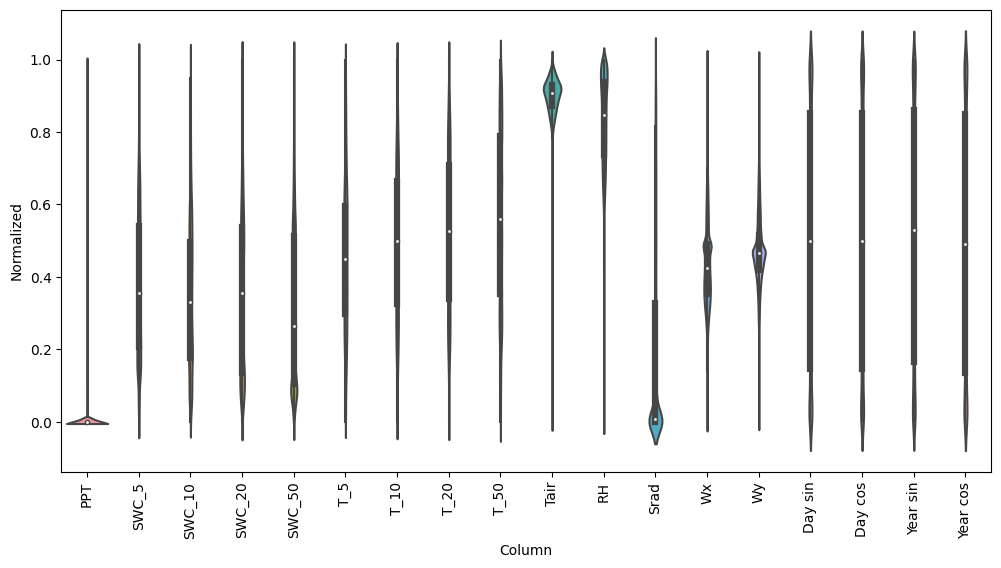

In [16]:
# df_std = (df - train_mean) / train_std
df_melted = norm_df.melt(var_name='Column', value_name='Normalized')


plt.figure(figsize=(12, 6))
ax = sns.violinplot(x='Column', y='Normalized', data=df_melted)
_ = ax.set_xticklabels(df.keys(), rotation=90)


In [17]:
norm_df.to_numpy()

array([[0.        , 0.36226415, 0.43925234, ..., 1.        , 0.50075262,
        0.99999943],
       [0.        , 0.36226415, 0.43925234, ..., 0.98296291, 0.50111101,
        0.99999877],
       [0.        , 0.36226415, 0.43925234, ..., 0.9330127 , 0.5014694 ,
        0.99999784],
       ...,
       [0.        , 0.2       , 0.08878505, ..., 0.9330127 , 0.06675453,
        0.2504036 ],
       [0.        , 0.2       , 0.08411215, ..., 0.98296291, 0.06657574,
        0.2507142 ],
       [0.        , 0.19622642, 0.08411215, ..., 1.        , 0.06639716,
        0.25102494]])

In [18]:
# Single step Batch generator

def batch_generator(df, label_column, window_size=5):
    
    label_col = df[label_column].to_numpy()
    df_as_np = df.drop(label_column, axis=1).to_numpy()
    
    X = []
    y = []
    for i in range(len(df_as_np) - window_size):
        row = [a for a in df_as_np[i:i+window_size]]
        X.append(row)
        label = label_col[i + window_size]
        y.append(label)
    return np.array(X), np.array(y)

In [19]:
WINDOW_SIZE = 24
X1, y1 = batch_generator(norm_df,'SWC_5', WINDOW_SIZE)

In [20]:
X1

array([[[0.        , 0.43925234, 0.41610738, ..., 1.        ,
         0.50075262, 0.99999943],
        [0.        , 0.43925234, 0.41610738, ..., 0.98296291,
         0.50111101, 0.99999877],
        [0.        , 0.43925234, 0.41610738, ..., 0.9330127 ,
         0.5014694 , 0.99999784],
        ...,
        [0.00592979, 0.43925234, 0.41610738, ..., 0.85355339,
         0.50827846, 0.99993146],
        [0.        , 0.43925234, 0.41610738, ..., 0.9330127 ,
         0.5086368 , 0.9999254 ],
        [0.        , 0.43925234, 0.41610738, ..., 0.98296291,
         0.50899513, 0.99991908]],

       [[0.        , 0.43925234, 0.41610738, ..., 0.98296291,
         0.50111101, 0.99999877],
        [0.        , 0.43925234, 0.41610738, ..., 0.9330127 ,
         0.5014694 , 0.99999784],
        [0.        , 0.43925234, 0.41610738, ..., 0.85355339,
         0.50182779, 0.99999666],
        ...,
        [0.        , 0.43925234, 0.41610738, ..., 0.9330127 ,
         0.5086368 , 0.9999254 ],
        [0. 

In [21]:
y1

array([0.40377358, 0.40377358, 0.40377358, ..., 0.2       , 0.2       ,
       0.19622642])

In [22]:
# (batch, time, features)
X1.shape, y1.shape

((57562, 24, 17), (57562,))

# Modeling

In [23]:
# One year validation 
# One year testing 
# 365*24 is one year 

X_train1, y_train1 = X1[:len(X1) - 365*24*2], y1[:len(X1) - 365*24*2]
X_val1, y_val1 = X1[len(X_train1):len(X_train1) + 365*24], y1[len(X_train1):len(X_train1) + 365*24]
X_test1, y_test1 = X1[len(X_train1)+ 365*24:len(X_train1) + 2* 365*24], y1[len(X_train1)+ 365*24:len(X_train1) + 2*365*24]
X1.shape, y1.shape, X_train1.shape, y_train1.shape, X_val1.shape, y_val1.shape, X_test1.shape, y_test1.shape

((57562, 24, 17),
 (57562,),
 (40042, 24, 17),
 (40042,),
 (8760, 24, 17),
 (8760,),
 (8760, 24, 17),
 (8760,))

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam

model1 = Sequential()
model1.add(InputLayer((24, 17)))
model1.add(LSTM(128, return_sequences=True))
model1.add(LSTM(64))
model1.add(Dense(16, 'relu'))
model1.add(Dense(1, 'linear'))

model1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 24, 128)           74752     
                                                                 
 lstm_1 (LSTM)               (None, 64)                49408     
                                                                 
 dense (Dense)               (None, 16)                1040      
                                                                 
 dense_1 (Dense)             (None, 1)                 17        
                                                                 
Total params: 125,217
Trainable params: 125,217
Non-trainable params: 0
_________________________________________________________________


In [25]:
MAX_EPOCHS = 100
# patience	Number of epochs with no improvement after which training will be stopped.

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=2,
                                                    mode='min')

cp1 = ModelCheckpoint('model1/', save_best_only=True)
model1.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

In [26]:
model1.fit(X_train1, y_train1, validation_data=(X_val1, y_val1), epochs=MAX_EPOCHS, callbacks=[cp1, early_stopping])

Epoch 1/100
1252/1252 [==============================] - 56s 41ms/step - loss: 0.0091 - root_mean_squared_error: 0.0953 - val_loss: 0.0157 - val_root_mean_squared_error: 0.1255
Epoch 2/100
1252/1252 [==============================] - 39s 31ms/step - loss: 0.0063 - root_mean_squared_error: 0.0791 - val_loss: 0.0239 - val_root_mean_squared_error: 0.1546
Epoch 3/100
1252/1252 [==============================] - 43s 34ms/step - loss: 0.0052 - root_mean_squared_error: 0.0720 - val_loss: 0.0166 - val_root_mean_squared_error: 0.1288


In [27]:
from tensorflow.keras.models import load_model
model1 = load_model('model1/')

In [28]:
train_predictions = model1.predict(X_train1).flatten()
train_results = pd.DataFrame(data={'Train Predictions':train_predictions, 'Actuals':y_train1})
train_results

1252/1252 [==============================] - 13s 10ms/step


,Train Predictions,Actuals
0,0.464794,0.403774
1,0.466163,0.403774
2,0.468546,0.403774
3,0.471400,0.403774
4,0.473555,0.407547
...,...,...
40037,0.156071,0.698113
40038,0.190731,0.683019
40039,0.222297,0.664151
40040,0.251963,0.641509


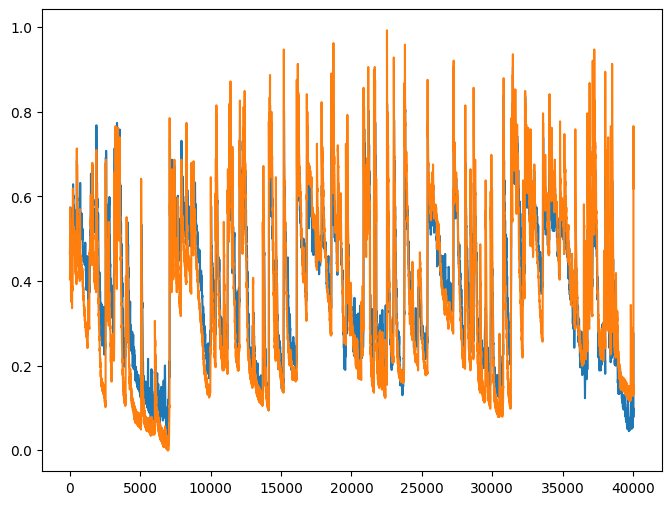

In [29]:
import matplotlib.pyplot as plt
plt.plot(train_results['Train Predictions'])
plt.plot(train_results['Actuals'])

In [30]:
X_test1.shape, y_test1.shape

((8760, 24, 17), (8760,))

In [31]:
test_predictions = model1.predict(X_test1).flatten()
test_results = pd.DataFrame(data={'Train Predictions':test_predictions, 'Actuals':y_test1})
train_results

274/274 [==============================] - 3s 10ms/step


,Train Predictions,Actuals
0,0.464794,0.403774
1,0.466163,0.403774
2,0.468546,0.403774
3,0.471400,0.403774
4,0.473555,0.407547
...,...,...
40037,0.156071,0.698113
40038,0.190731,0.683019
40039,0.222297,0.664151
40040,0.251963,0.641509


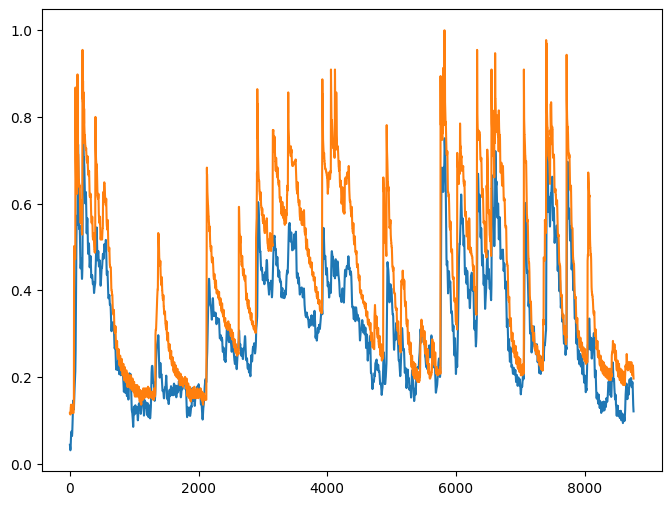

In [32]:
plt.plot(test_results['Train Predictions'])
plt.plot(test_results['Actuals'])

In [33]:
from sklearn.metrics import mean_squared_error as mse

def plot_predictions1(model, X, y):
    predictions = model.predict(X).flatten()
    
    df = pd.DataFrame(data={'Predictions':predictions, 'Actuals':y})
    
    plt.plot(df['Predictions'])
    plt.plot(df['Actuals'])
    

    
    return df, mse(y, predictions)

274/274 [==============================] - 3s 10ms/step
MSE is: 0.01876969847621599


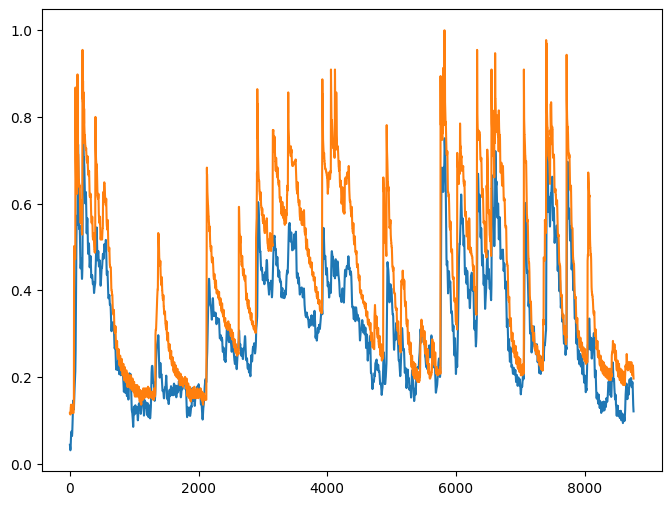

In [34]:
_, mse = plot_predictions1(model1, X_test1, y_test1)

print("MSE is:", mse)